**Resuming Screening** V2

In [1]:
# Cell 1 - Install dependencies
%pip install -q pandas numpy matplotlib python-docx pdfminer.six scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os 
import re 
import json
import textwrap
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from docx import Document
from pdfminer.high_level import extract_text as pdf_extract_text

core functions

In [5]:
#Text Cleaning

def clean_text(text):
    if not text:
        return ""
    text=text.replace("\r\n","\n").replace("\r","\n")
    text=re.sub(r"https\S+|www\.\S+"," ",text)
    text=re.sub(r"[^A-Za-z0-9\s.\-\,/]+", " ", text)
    text=re.sub(r"\s+"," ",text)
    return text.strip()

In [6]:
#Resume Parser for PDF,Docx,and TXT

def parse_resume_file(file_path):
    path=Path(file_path)
    ext = path.suffix.lower()

    if ext == ".pdf":
        text=pdf_extract_text(str(path))
        return clean_text(text)
    
    if ext in {".docx",".doc"}:
        doc = Document(path)
        paragraphs=[p.text for p in doc.paragraphs if p.text.strip()]
        return clean_text("\n".join(paragraphs))
    
    if ext in {".txt",".md"}:
        return clean_text(path.read_text(encoding="utf-8",errors="ignore"))
    
    raise ValueError(f"Unsupported file type: {ext}")

In [7]:
#Skill extraction
SKILL_TAXONOMY = [
    "python", "fastapi", "django", "flask", "java", "javascript", "typescript",
    "react", "nodejs", "sql", "postgresql", "mysql", "mongodb", "docker",
    "kubernetes", "aws", "azure", "git", "linux", "rest api", "microservices",
    "pytest", "ci/cd", "agile", "machine learning", "data science", "pandas",
    "numpy", "scikit-learn", "tensorflow", "pytorch", "tableau", "power bi"
]

def extract_skills(text):
    text_lower=text.lower()
    matches=[]
    for skill in SKILL_TAXONOMY:
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern,text_lower):
            matches.append(skill)
    return matches

In [8]:
#ATS Scoring Function
def score_resume_against_jd(resume_text,jd_text):
    resume_clean = clean_text(resume_text)
    jd_clean = clean_text(jd_text)

    resume_keywords=set(extract_skills(resume_clean))
    jd_keywords=set(extract_skills(jd_clean))

    matched_keywords=sorted(resume_keywords & jd_keywords)
    missing_keywords=sorted(jd_keywords - resume_keywords)

    #Semantic similarity using TF-IDF +cosine similarity
    vectorizer=TfidfVectorizer(stop_words="english",ngram_range=(1,2))
    matrix=vectorizer.fit_transform([resume_clean,jd_clean])
    semantic_score=cosine_similarity(matrix[0:1],matrix[1:2])[0][0]

    semantic_score=max(0.0,min(1.0,float(semantic_score)))
    keyword_score=len(matched_keywords)/max(len(jd_keywords),1)

    #simple heurisitic for experience signal
    exp_signal = 1.0 if re.search(r"\b(\d+)\+?\s*(years?|yrs?)\b",resume_clean.lower()) else 0.5

    #simple structure/format signal
    word_count=len(resume_clean.split())
    format_score=min(1.0,0.4+min(0.6,word_count/1000))

    ats_score=round(
        100*(
            0.45*semantic_score +
            0.35 *keyword_score +
            0.10 * exp_signal +
            0.10 * format_score
        ),
        1
    )

    return {
        "ats_score":ats_score,
        "semantic_score":round(semantic_score*100,1),
        "keyword_score":round(keyword_score * 100,1),
        "matched_keywords":matched_keywords,
        "missing_keywords":missing_keywords,
        "resume_word_count":word_count,
    }

In [9]:
#Example job description
job_description=""" 
We are hiring a Backend Python Engineer with strong experience in FastAPI, PostgreSQL, Docker, AWS, REST APIs,
and CI/CD. The ideal candidate should also have good testing skills, problem-solving ability, and experience building scalable services.
"""

In [10]:
#resume sample for experimentation

sample_resume={"Strong Match": """
    John Doe
    Backend Python Developer

    Experience:
    - Built REST APIs using FastAPI and Python
    - Designed PostgreSQL databases and optimized queries
    - Deployed services using Docker and AWS
    - Worked with CI/CD pipelines and pytest

    Skills:
    Python, FastAPI, PostgreSQL, Docker, AWS, REST API, pytest, CI/CD
    """,
    "Partial Match": """
    Jane Smith
    Software Engineer

    Experience:
    - Worked on Java and Spring Boot applications
    - Built frontend features with React
    - Used SQL and Git in daily work

    Skills:
    Java, Spring Boot, React, SQL, Git
    """,
    "Weak Match": """
    Alex Brown
    Marketing Specialist

    Experience:
    - Managed social media campaigns
    - Wrote content and coordinated events
    - Worked in customer support

    Skills:
    Marketing, Social Media, Content Writing, Communication
    """
}

In [11]:
#Scoring all sample resumes 
rows=[]

for candidate_name, resume_text in sample_resume.items():
    result = score_resume_against_jd(resume_text,job_description)
    rows.append({
        "candidate":candidate_name,
        **result
    })

df=pd.DataFrame(rows)
df=df.sort_values("ats_score",ascending=False)
df

,candidate,ats_score,semantic_score,keyword_score,matched_keywords,missing_keywords,resume_word_count
0,Strong Match,57.4,28.8,100.0,"[aws, ci/cd, docker, fastapi, postgresql, python]",[],45
1,Partial Match,10.9,3.5,0.0,[],"[aws, ci/cd, docker, fastapi, postgresql, python]",34
2,Weak Match,10.6,2.9,0.0,[],"[aws, ci/cd, docker, fastapi, postgresql, python]",28


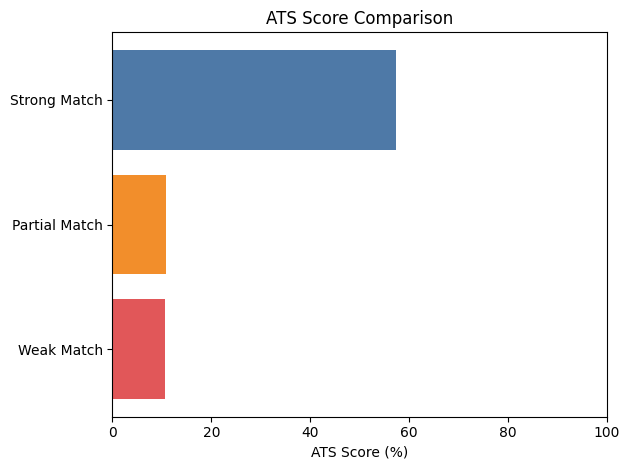

In [12]:
#Comparison Chart
plt.Figure(figsize=(8,4))
plt.barh(df["candidate"],df["ats_score"],color=["#4e79a7", "#f28e2b", "#e15759"])
plt.xlim(0,100)
plt.title("ATS Score Comparison")
plt.xlabel("ATS Score (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
#results to csv
df.to_csv("ats_experiment_result.csv",index=False)
df.to_csv("ats_exoeriment_result.csv",index=False)
print("Saved ")

Saved 


In [14]:
#Function to Process resumes from a folder 
def run_folder_experiment(folder_path):
    folder = Path(folder_path)
    rows=[]

    for file_path in sorted(folder.glob("*")):
        if file_path.suffix.lower() not in {".pdf",".docx",".doc",".txt",".md"}:
            continue

        try:
            resume_text = parse_resume_file(file_path)
            result=score_resume_against_jd(resume_text,job_description)
            rows.append({
                "file":file_path.name,
                **result
            })
        except Exception as e :
            print(f"Failed for {file_path.name}:{e}")
    
    return pd.DataFrame(rows)